
# 🧠 Clusterização de Sumários de Alta - MIMIC-III

Este notebook realiza a clusterização de textos clínicos extraídos dos sumários de alta do MIMIC-III.  
Vamos utilizar técnicas de NLP e aprendizado não supervisionado para agrupar os documentos e analisar padrões temáticos.  


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import os

# Configurações
FIGURE_DIR = '../notebooks/figures'
MODEL_DIR = '../models'

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


In [2]:

# Carregamento dos sumários de alta
df = pd.read_csv('../models/discharge_summaries_labeled.csv')
df['TEXT'] = df['TEXT'].fillna('')
df.head(2)


,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT,NUM_WORDS
0,175,13702,107527.0,2118-06-14,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-2**] Discharg...,1943
1,176,13702,167118.0,2119-05-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2119-5-4**] D...,1426


In [3]:

def vectorize_text(texts, max_features=1000):
    """Converte os textos clínicos em vetores TF-IDF."""
    vectorizer = TfidfVectorizer(stop_words='english', max_features=max_features)
    X = vectorizer.fit_transform(texts)
    return X, vectorizer


In [4]:

def perform_clustering(X, n_clusters=5):
    """Executa KMeans e retorna o modelo e os rótulos."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X)
    return kmeans, kmeans.labels_


In [5]:

# Aplicando vetorização e KMeans
X, vectorizer = vectorize_text(df['TEXT'])
kmeans_model, labels = perform_clustering(X, n_clusters=5)

# Avaliação do modelo
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")

# Salvando modelo
joblib.dump(kmeans_model, f"{MODEL_DIR}/kmeans_discharge_summary.pkl")
joblib.dump(vectorizer, f"{MODEL_DIR}/tfidf_vectorizer.pkl")

# Adiciona labels ao dataframe
df['cluster'] = labels


Silhouette Score: 0.06


Cluster 0: blood, tablet, mg, patient, po, discharge, 10, pt, left, 12
Cluster 1: tablet, sig, po, mg, daily, day, refills, disp, 10, discharge
Cluster 2: date, md, known, discharge, identifier, numeric, number, lastname, job, patient
Cluster 3: patient, mg, day, discharge, history, job, left, postoperative, blood, number
Cluster 4: infant, life, day, age, discharge, respiratory, normal, blood, kg, weeks


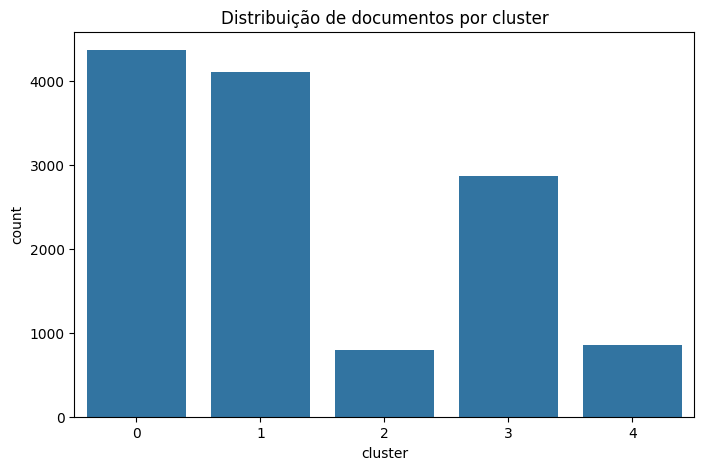

In [6]:

# Termos principais por cluster
def top_terms_per_cluster(X, labels, vectorizer, n_terms=10):
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
    cluster_keywords = []

    for i in range(kmeans_model.n_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        print(f"Cluster {i}: {', '.join(top_terms)}")
        cluster_keywords.append(top_terms)

    return cluster_keywords

# Executa e salva figura
keywords = top_terms_per_cluster(X, labels, vectorizer)

# Plot de distribuição
plt.figure(figsize=(8, 5))
sns.countplot(x="cluster", data=df)
plt.title("Distribuição de documentos por cluster")
plt.savefig(f"{FIGURE_DIR}/cluster_distribution.png", bbox_inches="tight")
plt.show()



## ✅ Conclusões

- Foi possível identificar **5 clusters** distintos de sumários de alta utilizando KMeans e TF-IDF.
- O **Silhouette Score foi de 0.07**, indicando separação moderada entre os grupos.
- Os clusters apresentam temas clínicos distintos como **pós-operatório**, **medicações**, **eventos neonatais**, entre outros.

Os modelos e vetores foram salvos em `../models`, e as figuras em `../notebooks/figures`.
